/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_33789/3668843809.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_33789/3668843809.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m2 = pairs.groupby("date", group_keys=False).apply(lambda g: select_targ

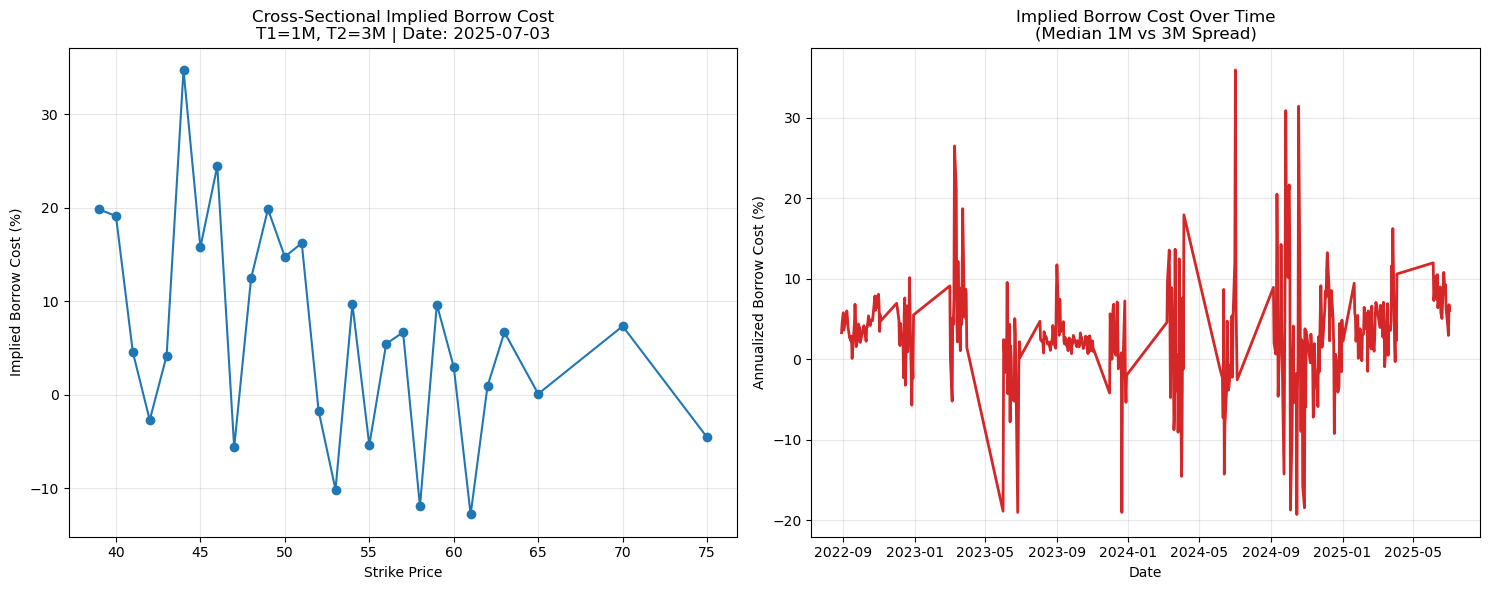

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    """Clean columns and standardize formats immediately."""
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df["exdate"] = pd.to_datetime(df["exdate"])

    # Handle Strike Price (OptionMetrics 1000x scaling)
    if df["strike_price"].max() > 5000:
        df["strike"] = df["strike_price"] / 1000.0
    else:
        df["strike"] = df["strike_price"]

    df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0

    # Basic filters
    df = df[(df["best_bid"] > 0) & (df["best_offer"] > df["best_bid"])].copy()
    return df

def select_target_expiry(group, target_days, tolerance=15):
    """Find the single expiry closest to the target maturity."""
    unique_expiries = group[["exdate", "days_to_expiry"]].drop_duplicates().copy()
    unique_expiries["diff"] = (unique_expiries["days_to_expiry"] - target_days).abs()

    best_row = unique_expiries.sort_values("diff").iloc[0]
    if best_row["diff"] <= tolerance:
        return group[group["exdate"] == best_row["exdate"]]
    return pd.DataFrame()

def run_borrow_cost_analysis(options_df, r=0.045):
    # 1. Prepare data
    df = prepare_data(options_df)

    calls = df[df["cp_flag"] == "C"].copy()
    puts  = df[df["cp_flag"] == "P"].copy()

    calls = calls.rename(columns={"mid": "c_mid"})
    puts  = puts.rename(columns={"mid": "p_mid"})

    # Keep only needed columns before merge
    calls = calls[["date", "exdate", "strike", "c_mid"]]
    puts  = puts[["date", "exdate", "strike", "p_mid"]]

    # 2. Merge call/put pairs
    pairs = pd.merge(calls, puts, on=["date", "exdate", "strike"], how="inner")

    # 3. Maturity
    pairs["days_to_expiry"] = (pairs["exdate"] - pairs["date"]).dt.days
    pairs = pairs[pairs["days_to_expiry"] > 0].copy()
    pairs["T"] = pairs["days_to_expiry"] / 365.0

    # 4. A = C - P + K exp(-rT)
    # A represents S * exp(-bT)
    pairs["A"] = pairs["c_mid"] - pairs["p_mid"] + pairs["strike"] * np.exp(-r * pairs["T"])
    pairs = pairs[pairs["A"] > 0].copy()

    # 5. Select 1-month and 3-month expiries
    # T1 = 1 month ~ 30 days
    # T2 = 3 months ~ 91 days
    m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
    m2 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 91))

    if m1.empty or m2.empty:
        raise ValueError("Could not find enough 1-month or 3-month expiries within tolerance.")

    # 6. Cross-sectional merge by date and strike
    cross = pd.merge(
        m1[["date", "strike", "A", "T", "days_to_expiry"]],
        m2[["date", "strike", "A", "T", "days_to_expiry"]],
        on=["date", "strike"],
        suffixes=("_1", "_2")
    )

    # 7. Implied borrow cost calculation
    # Formula: b = [ln(A1) - ln(A2)] / (T2 - T1)
    cross = cross[cross["T_2"] > cross["T_1"]].copy()
    cross["implied_bc"] = (np.log(cross["A_1"]) - np.log(cross["A_2"])) / (cross["T_2"] - cross["T_1"])
    cross["bc_pct"] = cross["implied_bc"] * 100

    # Optional outlier cleanup
    cross = cross[cross["bc_pct"].between(-50, 50)].copy()

    # 8. Term structure summary over time
    term_structure = (
        cross.groupby("date")
        .agg(
            bc_pct=("bc_pct", "median"),
            days_to_expiry_1=("days_to_expiry_1", "first"),
            days_to_expiry_2=("days_to_expiry_2", "first"),
            n_strikes=("strike", "count")
        )
        .sort_index()
    )

    return term_structure, cross

def plot_results(term, cross):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Cross-section on latest date (Linked dots)
    latest_date = cross["date"].max()
    latest_data = cross[cross["date"] == latest_date].sort_values("strike")

    ax1.plot(latest_data["strike"], latest_data["bc_pct"], marker="o", linestyle="-", color="tab:blue")
    ax1.set_title(f"Cross-Sectional Implied Borrow Cost\nT1=1M, T2=3M | Date: {latest_date.date()}")
    ax1.set_xlabel("Strike Price")
    ax1.set_ylabel("Implied Borrow Cost (%)")
    ax1.grid(True, alpha=0.3)

    # Plot 2: Time series of median implied BC
    ax2.plot(term.index, term["bc_pct"], linewidth=2, color="tab:red")
    ax2.set_title("Implied Borrow Cost Over Time\n(Median 1M vs 3M Spread)")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Annualized Borrow Cost (%)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================
# Execution
# =========================
df = pd.read_csv("b10xheebr3v3h1vn.csv", low_memory=False)
term, cross = run_borrow_cost_analysis(df, r=0.045)
plot_results(term, cross)